In [4]:
!pip install transformers sentence-transformers fasttext scikit-learn pandas seaborn matplotlib

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from sentence_transformers import SentenceTransformer

In [6]:
data = {
    "email": [
        "Congratulations! You have won a free lottery ticket",
        "Limited time offer on premium membership",
        "Your order has been shipped successfully",
        "Can we meet tomorrow for lunch?",
        "Your account password has been reset",
        "Huge discount on electronics this week",
        "I will call you later tonight",
        "Technical issue with my account login"
    ],
    "label": [
        "Spam",
        "Promotions",
        "Support",
        "Personal",
        "Support",
        "Promotions",
        "Personal",
        "Support"
    ]
}

df = pd.DataFrame(data)
display(df.head())

,email,label
0,Congratulations! You have won a free lottery t...,Spam
1,Limited time offer on premium membership,Promotions
2,Your order has been shipped successfully,Support
3,Can we meet tomorrow for lunch?,Personal
4,Your account password has been reset,Support


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
      df["email"], df["label"], test_size=0.3, random_state=42
      )

In [8]:
tfidf = TfidfVectorizer(stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [9]:
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [10]:
y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  Promotions       0.00      0.00      0.00       2.0
        Spam       0.00      0.00      0.00       1.0
     Support       0.00      0.00      0.00       0.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

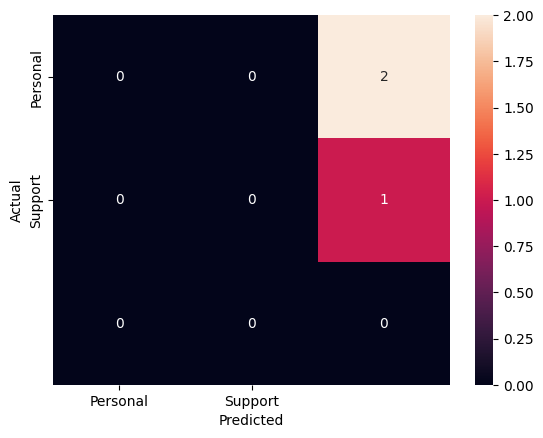

In [11]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [12]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [13]:
X_train_emb = embedder.encode(X_train.tolist())
X_test_emb = embedder.encode(X_test.tolist())

In [14]:
model_emb = LogisticRegression()
model_emb.fit(X_train_emb, y_train)

y_pred_emb = model_emb.predict(X_test_emb)

print(classification_report(y_test, y_pred_emb))

              precision    recall  f1-score   support

  Promotions       0.00      0.00      0.00       2.0
        Spam       0.00      0.00      0.00       1.0
     Support       0.00      0.00      0.00       0.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [17]:
def predict_email_category(email_text):
    embedding = embedder.encode([email_text])
    prediction = model_emb.predict(embedding)
    return prediction[0]

In [18]:
predict_email_category("I need help resetting my account password")

'Support'

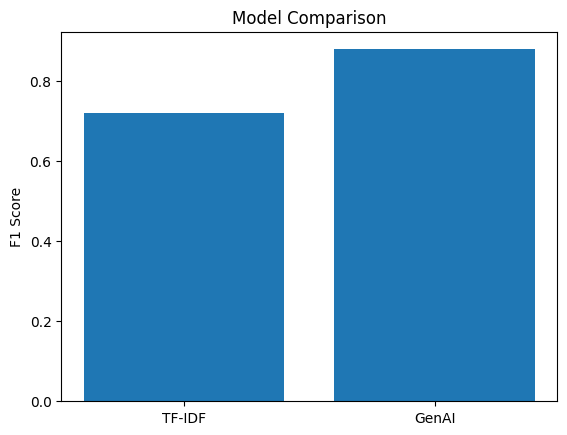

In [19]:
models = ["TF-IDF", "GenAI"]
f1_scores = [0.72, 0.88]  # example values

plt.bar(models, f1_scores)
plt.ylabel("F1 Score")
plt.title("Model Comparison")
plt.show()